In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from skimage import io
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu, threshold_triangle
from skimage import measure
from skimage.measure import label, regionprops, regionprops_table
from skimage.morphology import opening, disk
from scipy import ndimage
import pickle

pd.set_option('display.max_rows', None)


class datapoint():
    def __init__(self, datapoint = np.array([])):
        self.data = {}
        self.datapoint = datapoint

    def add(self, more_data:dict):
        for k in more_data:
            self.data[k] = more_data[k]
            self.datapoint = np.append(self.datapoint, more_data[k])
        self.datapoint = self.datapoint.flatten()
        self.mean, self.sd = self.calculate()
        

    def drop(self, drop_data:list):
        new_data = {}
        new_datapoint = np.array([])
        for k in self.data:
            if k not in drop_data:
                new_data[k] = self.data[k]
                new_datapoint = np.append(new_datapoint, new_data[k])
        self.datapoint = new_datapoint
        self.data = new_data
        self.datapoint = self.datapoint.flatten()
        self.mean, self.sd = self.calculate()


    def calculate(self):
        mean= np.mean(self.datapoint)
        sd_err = np.std(self.datapoint)/ np.sqrt(len(self.datapoint))
        return mean, sd_err
    

    def save(self, save_path):
        with open(save_path, 'wb') as f:
            pickle.dump(self.data, f)

    def load(self, load_path):
        with open(load_path, 'rb') as f:
            self.data = pickle.load(f)
        for k in self.data:
            self.datapoint = np.append(self.datapoint, self.data[k])

In [3]:
#load images
imgs = {}
for file in os.listdir():
    if file[-4:] == ".jpg":
        img = io.imread(file, as_gray = 1)
        #img = rgb2gray(img)
        imgs[file[:-4]] = img

In [4]:
imgs.keys()

dict_keys(['sos_akt_Dark', 'sos_akt_Light'])

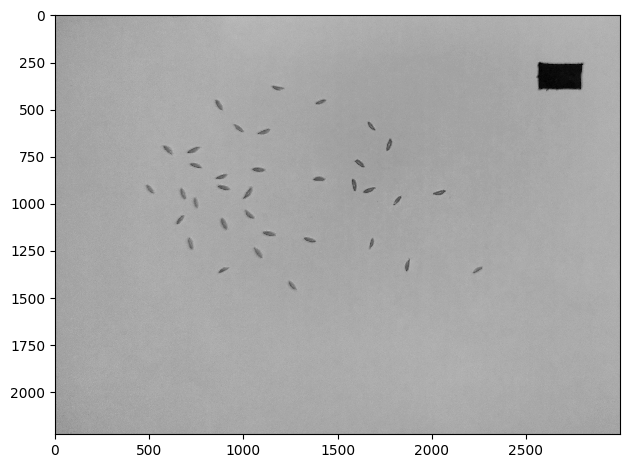

In [5]:
io.imshow(imgs['sos_akt_Dark'][800:,:3000])

In [6]:
#split experiments
#crop images for analysis
expimgcs = {}
for img in imgs:
    if img =="sos_akt_Dark":
        imgc = imgs[img][800:,:3000]
    else:

        imgc = imgs[img][1100:,:2500]
    expimgcs[img] = imgc

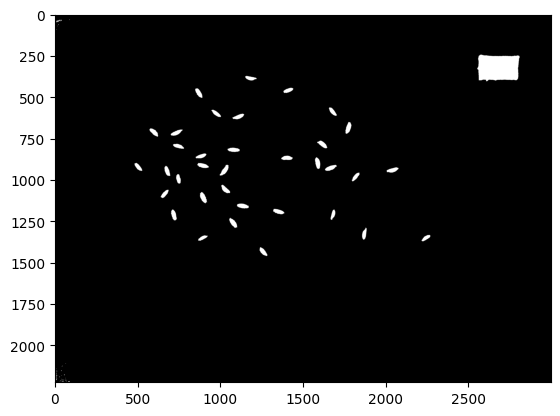

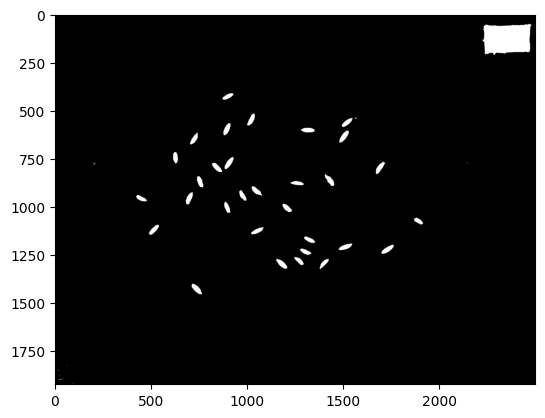

In [7]:
from skimage.filters import threshold_otsu, threshold_triangle, threshold_yen


dict_raw = {}


for n, k in enumerate(expimgcs):
    img = expimgcs[k]
    imgt = threshold_yen(img)

    imgto = img<imgt

    label1_imgto = label(imgto, connectivity =2)
    label1_imgtob = ndimage.binary_fill_holes(label1_imgto >0)
    footprint = disk(1)
    label1_imgtobo = opening(label1_imgtob, footprint)
    
    fig, ax = plt.subplots()
    ax.imshow(label1_imgtobo, cmap=plt.cm.gray)

    label2_imgto = label(label1_imgtobo, connectivity =2)

    df = pd.DataFrame(regionprops_table(label2_imgto, properties=('area',
                                             'axis_major_length',
                                             'axis_minor_length')))

    df_use = df.loc[[i for i in df.index if df.loc[i]["area"] >300]]
    df_use["setup"] = k[:-1]
    dict_raw[k] = df_use

In [8]:
dict_cal = {}

for k in dict_raw:
    raw_drop = dict_raw[k].copy()
    for ind in raw_drop.index:
        if raw_drop.loc[ind]["area"] >12000:
            norm = raw_drop.loc[ind]["axis_major_length"]
            raw_drop = raw_drop.drop([ind])
        elif raw_drop.loc[ind]["area"]<800 or raw_drop.loc[ind]["area"]>3000:
            raw_drop = raw_drop.drop([ind])
        elif raw_drop.loc[ind]["axis_major_length"]>100:
            raw_drop = raw_drop.drop([ind])
    cal_df = pd.DataFrame()
    cal_df["area"] = raw_drop["area"]/ (norm**2)
    cal_df["axis_major_length"] = raw_drop["axis_major_length"]/norm
    cal_df["axis_minor_length"] = raw_drop["axis_minor_length"]/norm
    cal_df["setup"] = raw_drop["setup"]
    
    dict_cal[k] = cal_df

In [9]:
dict_cal.keys()

dict_keys(['sos_akt_Dark', 'sos_akt_Light'])

In [15]:
sos_akt_light = datapoint()
sos_akt_dark = datapoint()

sos_akt_light.add({"sos_akt_light": np.array(dict_cal["sos_akt_Light"]["axis_major_length"])})
sos_akt_dark.add({"sos_akt_dark": np.array(dict_cal['sos_akt_Dark']["axis_major_length"])})

In [13]:
topto_light = datapoint()
topto_light.load("topto-light.pkl")
topto_dark = datapoint()
topto_dark.load("topto-dark.pkl")
PhmW_light = datapoint()
PhmW_light.load("PhmW-light.pkl")
PhmW_dark = datapoint()
PhmW_dark.load("PhmW-dark.pkl")
optoakt_light = datapoint()
optoakt_light.load("optoakt_light.pkl")
optoakt_dark = datapoint()
optoakt_dark.load("optoakt_dark.pkl")
rasv12 = datapoint()
rasv12.load("rasv12.pkl")

In [18]:
np.mean(dict_cal['rasv12 size']["axis_major_length"]),np.min(dict_cal['rasv12 size']["axis_major_length"]),np.max(dict_cal['rasv12 size']["axis_major_length"])

(0.22792549236264473, 0.19859391667495388, 0.2604300097052285)

In [39]:
def hourglass_shp(scatters, xval, width=0.2):
    lst = []
    mu = np.mean(scatters)
    max_dif = np.max([np.max(scatters) - mu, mu- np.min(scatters)])
    for s in scatters:
        if np.abs((np.abs(s-mu) - max_dif)*1000) <1:
            dis = 0
        elif np.random.randint(0,2):
            dis = np.random.randint(0, np.abs((np.abs(s-mu) - max_dif)*1000))/1000*width
        else:
            dis = -np.random.randint(0, np.abs((np.abs(s-mu)-  max_dif)*1000))/1000*width
        
        lst.append(xval + 10*dis)
    return lst

In [41]:
 xval_hourglass

[6.988,
 6.996,
 7.034,
 7.042,
 7.068,
 6.986,
 6.998,
 6.968,
 7.01,
 6.972,
 6.994,
 7.018,
 7.06,
 6.964,
 7.008,
 6.99,
 7.024,
 7,
 6.976,
 6.994,
 7.02,
 7.038,
 7.002,
 7.014,
 6.968,
 6.984,
 7.032,
 6.94,
 7.05,
 6.982,
 6.958,
 6.956,
 7.024,
 7.0,
 7.04]

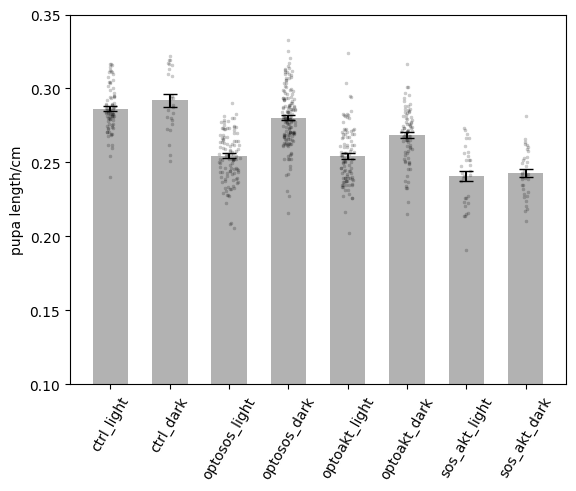

In [ ]:
lst = [PhmW_light,PhmW_dark,topto_light,topto_dark,optoakt_light,optoakt_dark,sos_akt_light,sos_akt_dark]
for n in range(len(lst)):
    xval = [n for l in range(len(lst[n].datapoint))]
    xval_hourglass= hourglass_shp(lst[n].datapoint, xval[0])
    mean, sd = lst[n].calculate()
    plt.scatter(xval_hourglass, lst[n].datapoint, s = 3, marker = "x", color = (0,0,0, 0.2))
    plt.bar(n, mean, width = 0.6, color = (0,0,0,0.3), yerr = sd, capsize=5)

#plt.xticks(range(len(lst)),[len(lst[n].datapoint) for n in range(len(lst))], rotation = 60)
plt.xticks(range(len(lst)),['ctrl_light','ctrl_dark','optosos_light','optosos_dark','optoakt_light','optoakt_dark','sos_akt_light','sos_akt_dark'], rotation = 60)
plt.ylabel("pupa length/cm")
plt.ylim(0.1, 0.35)
plt.savefig("size compare rasv12 akt, sos")
plt.show()

In [27]:
import numpy as np
from scipy import stats


stats.ttest_ind(lst[0].datapoint, lst[1].datapoint, equal_var= True)

TtestResult(statistic=-1.3694853009199575, pvalue=0.1765162460795381, df=54.0)

In [28]:
stats.ttest_ind(lst[0].datapoint, lst[1].datapoint, equal_var= False)

TtestResult(statistic=-1.3736434487710274, pvalue=0.17543643551439006, df=52.08211574878243)